# 🏦 Bank Personal Loan Prediction

**Goal:** Predict whether a bank customer will accept a personal loan offer based on demographic and financial attributes.

**Models compared:** Logistic Regression · K-Nearest Neighbors · Naive Bayes

---

## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier as KNN
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import ComplementNB
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn import metrics
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import zipcodes as zp
from warnings import filterwarnings
filterwarnings('ignore')

# Consistent plot style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100


## 2. Load Data

Dataset: `Bank_Personal_Loan_Modelling.csv` — 5,000 customers with demographic, financial, and banking features.

| Column | Description |
|---|---|
| Age | Customer age |
| Experience | Years of professional experience |
| Income | Annual income ($000s) |
| ZIP Code | Home ZIP code |
| Family | Family size |
| CCAvg | Avg. monthly credit card spend |
| Education | 1=Undergrad, 2=Graduate, 3=Advanced |
| Mortgage | House mortgage value (0 = none) |
| **Personal Loan** | **Target: accepted loan offer?** |
| Securities Account | Has securities account |
| CD Account | Has CD account |
| Online | Uses internet banking |
| CreditCard | Has bank credit card |

In [3]:
df = pd.read_csv('../data/Bank_Personal_Loan_Modelling.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (5000, 14)


,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,1,25,1,49,91107,4,1/60,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1/50,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1/00,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2/70,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1/00,2,0,0,0,0,0,1


In [4]:
df.describe()

,ID,Age,Experience,Income,ZIP Code,Family,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000
mean,2500.500000,45.338400,20.104600,73.774200,93152.503000,2.396400,1.881000,56.498800,0.096000,0.104400,0.06040,0.596800,0.294000
std,1443.520003,11.463166,11.467954,46.033729,2121.852197,1.147663,0.839869,101.713802,0.294621,0.305809,0.23825,0.490589,0.455637
min,1.000000,23.000000,-3.000000,8.000000,9307.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
25%,1250.750000,35.000000,10.000000,39.000000,91911.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
50%,2500.500000,45.000000,20.000000,64.000000,93437.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.00000,1.000000,0.000000
75%,3750.250000,55.000000,30.000000,98.000000,94608.000000,3.000000,3.000000,101.000000,0.000000,0.000000,0.00000,1.000000,1.000000
max,5000.000000,67.000000,43.000000,224.000000,96651.000000,4.000000,3.000000,635.000000,1.000000,1.000000,1.00000,1.000000,1.000000


## 3. Data Preprocessing

### 3.1 Fix Negative Experience
A small number of rows have negative experience values — likely data-entry errors. Taking the absolute value corrects them.

In [5]:
print('Negative experience rows:', (df['Experience'] < 0).sum())
df['Experience'] = df['Experience'].abs()

Negative experience rows: 52


### 3.2 Drop Uninformative Columns
- `ID` — just a row identifier, no predictive value.
- `CCAvg` — removed as part of initial feature selection (correlated with Income).

In [6]:
df.drop(columns=['ID', 'CCAvg'], inplace=True)
print('Remaining columns:', df.columns.tolist())

Remaining columns: ['Age', 'Experience', 'Income', 'ZIP Code', 'Family', 'Education', 'Mortgage', 'Personal Loan', 'Securities Account', 'CD Account', 'Online', 'CreditCard']


### 3.3 Missing Values

In [7]:
missing = df.isnull().sum()
print(missing[missing > 0] if missing.any() else 'No missing values.')

No missing values.


## 4. Exploratory Data Analysis (EDA)

### 4.1 Target Distribution
The dataset is imbalanced — most customers did **not** accept the loan offer.

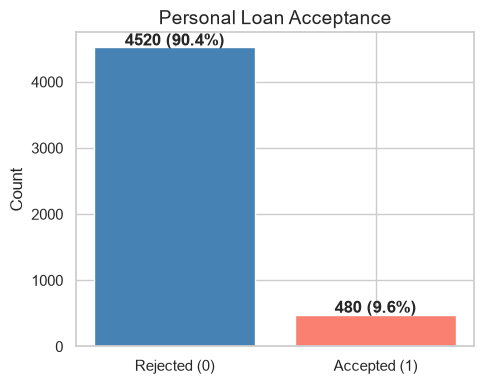

In [8]:
fig, ax = plt.subplots(figsize=(5, 4))
counts = df['Personal Loan'].value_counts()
ax.bar(['Rejected (0)', 'Accepted (1)'], counts, color=['steelblue', 'salmon'])
for i, v in enumerate(counts):
    ax.text(i, v + 30, f'{v} ({v/len(df)*100:.1f}%)', ha='center', fontweight='bold')
ax.set_title('Personal Loan Acceptance', fontsize=14)
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

### 4.2 Categorical Features

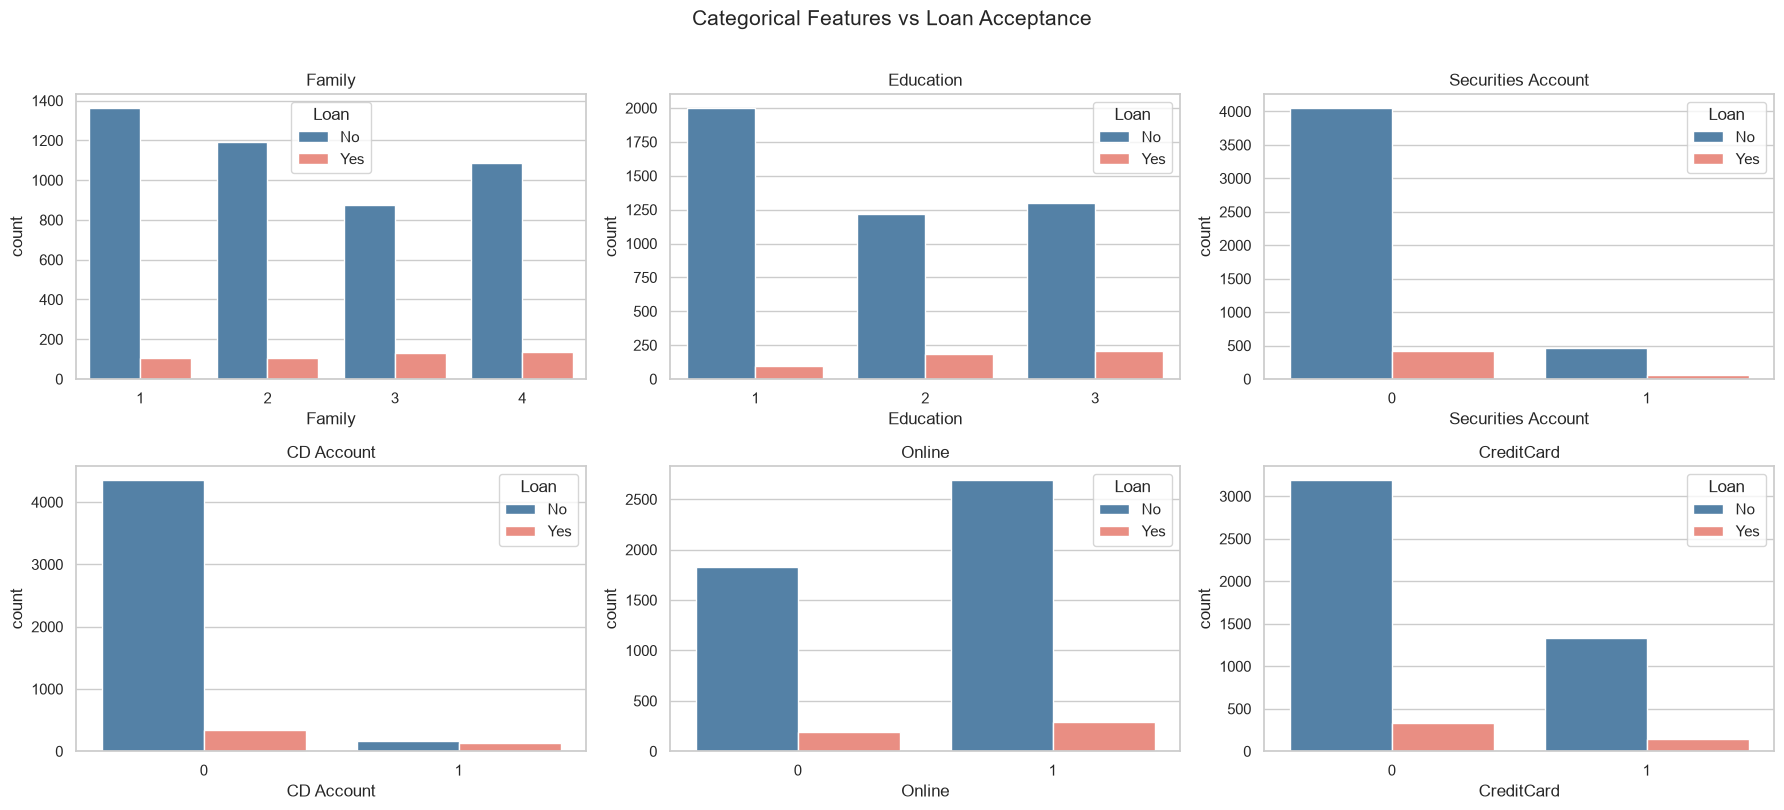

In [9]:
categorical = ['Family', 'Education', 'Securities Account', 'CD Account', 'Online', 'CreditCard']
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
for ax, col in zip(axes.flatten(), categorical):
    sns.countplot(x=col, hue='Personal Loan', data=df, ax=ax, palette=['steelblue', 'salmon'])
    ax.set_title(col, fontsize=12)
    ax.legend(title='Loan', labels=['No', 'Yes'])
plt.suptitle('Categorical Features vs Loan Acceptance', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

### 4.3 Numerical Features — Distribution & Outliers

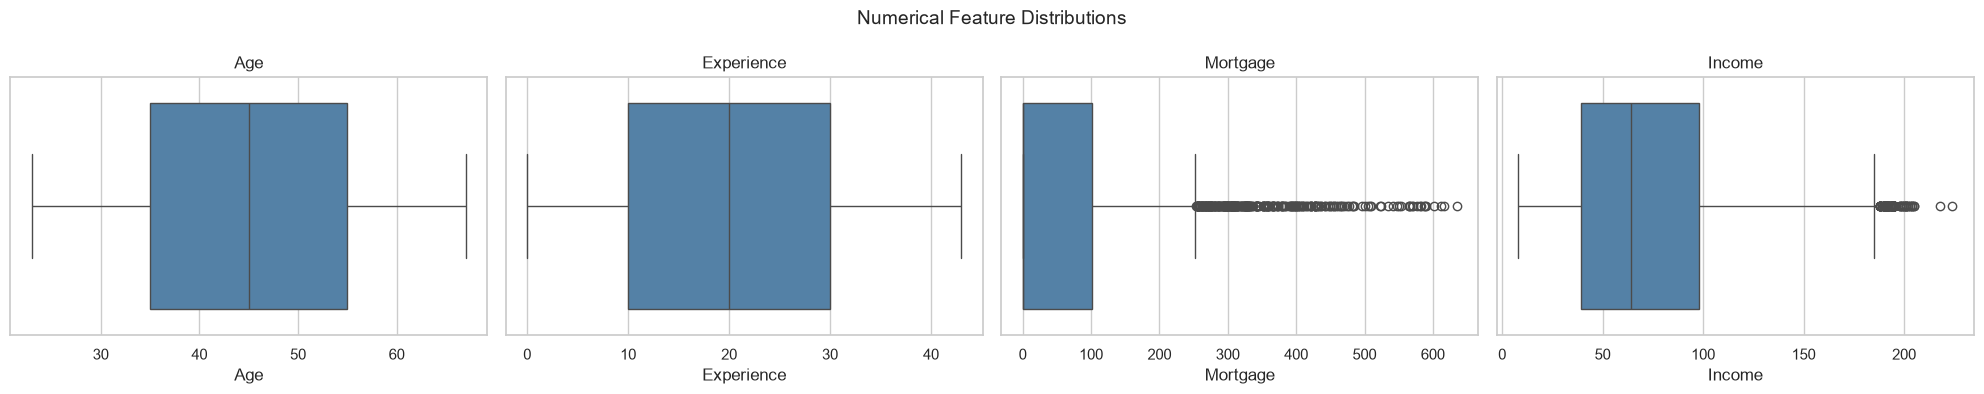

In [10]:
numerical = ['Age', 'Experience', 'Mortgage', 'Income']
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for ax, col in zip(axes, numerical):
    sns.boxplot(x=col, data=df, ax=ax, color='steelblue')
    ax.set_title(col)
plt.suptitle('Numerical Feature Distributions', fontsize=14)
plt.tight_layout()
plt.show()

### 4.4 Income vs Age by Loan Status

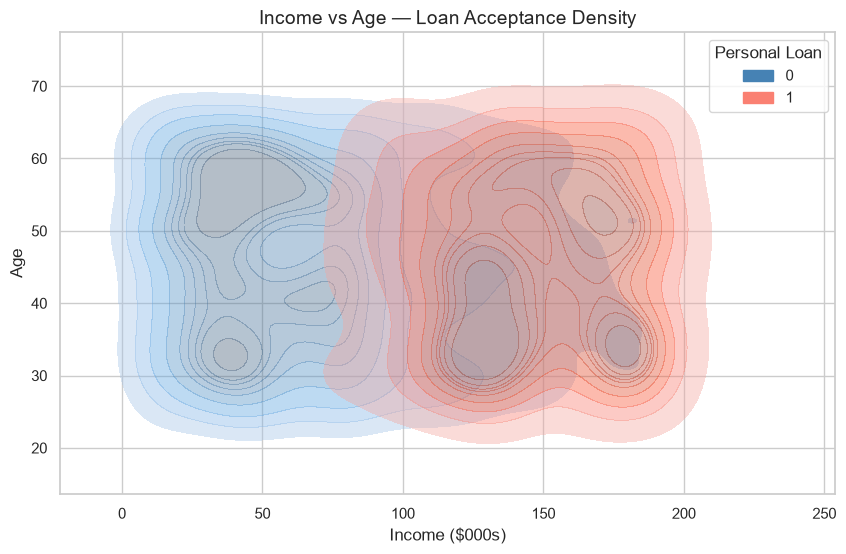

In [11]:
plt.figure(figsize=(10, 6))
sns.kdeplot(
    data=df, x='Income', y='Age',
    hue='Personal Loan', fill=True, common_norm=False,
    palette=['steelblue', 'salmon'], alpha=0.4, linewidth=0
)
plt.title('Income vs Age — Loan Acceptance Density', fontsize=14)
plt.xlabel('Income ($000s)', fontsize=12)
plt.ylabel('Age', fontsize=12)
plt.show()

### 4.5 Correlation Heatmap

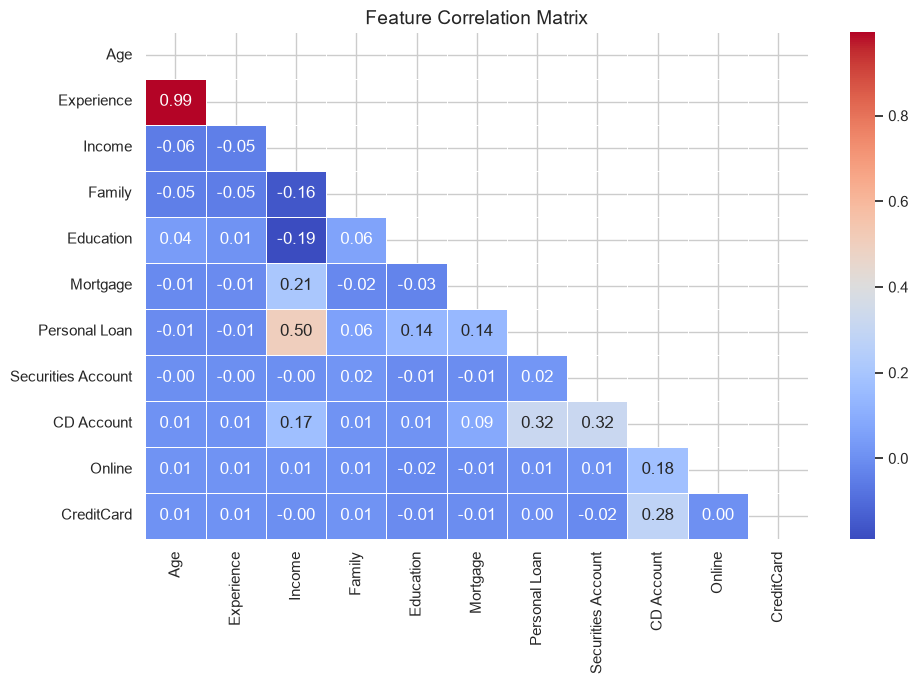

In [12]:
plt.figure(figsize=(10, 7))
corr = df.drop(columns=['ZIP Code']).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.show()

## 5. ZIP Code — Noise Detection & Geo-enrichment
ZIP codes below 20000 are outside California and are likely data entry errors.

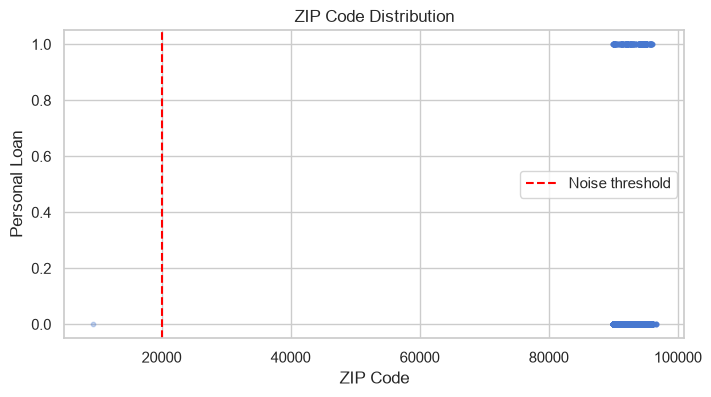

Noisy rows: 1


,Age,Experience,Income,ZIP Code,Family,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
384,51,25,21,9307,4,3,0,0,0,0,1,1


In [13]:
plt.figure(figsize=(8, 4))
plt.scatter(df['ZIP Code'], df['Personal Loan'], alpha=0.3, s=10)
plt.axvline(20000, color='red', linestyle='--', label='Noise threshold')
plt.xlabel('ZIP Code')
plt.ylabel('Personal Loan')
plt.title('ZIP Code Distribution')
plt.legend()
plt.show()

noisezip = df[df['ZIP Code'] < 20000]
print(f'Noisy rows: {len(noisezip)}')
noisezip

In [14]:
# Drop the single outlier row
df = df[df['ZIP Code'] >= 20000].reset_index(drop=True)
print(f'Rows after removing ZIP noise: {len(df)}')

Rows after removing ZIP noise: 4999


### 5.1 Enrich with Geographic Coordinates

In [15]:
country, lat, long = [], [], []
for x in df['ZIP Code']:
    match = zp.matching(str(x))
    if len(match) == 1:
        country.append(match[0].get('county'))
        lat.append(match[0].get('lat'))
        long.append(match[0].get('long'))
    else:
        country.append('Not Found')
        lat.append(np.nan)
        long.append(np.nan)

df['Place'] = country
df['Latitude'] = pd.to_numeric(lat, errors='coerce')
df['Longitude'] = pd.to_numeric(long, errors='coerce')

print(f"Missing geo entries: {df['Place'].eq('Not Found').sum()}")

Missing geo entries: 33


### 5.2 Manually Fix Known Missing ZIP Codes

In [16]:
zip_fixes = {
    92717: ('Irvine',       33.6462, -117.8398),
    96651: ('Coloma',       38.7974, -120.8771),
    92634: ('Fullerton',    33.8739, -117.9028),
}

for zipcode, (place, la, lo) in zip_fixes.items():
    mask = df['ZIP Code'] == zipcode
    df.loc[mask, 'Place']     = place
    df.loc[mask, 'Latitude']  = la
    df.loc[mask, 'Longitude'] = lo

remaining = df[df['Place'] == 'Not Found']
print(f'Still unfixed: {len(remaining)}')

Still unfixed: 0


## 6. Modeling

Features: all columns except `Personal Loan`, `Place`, `Latitude`, `Longitude` (geo info not predictive after ZIP enrichment).

Train / Test split: 80% / 20%

In [17]:
feature_cols = [c for c in df.columns if c not in ['Personal Loan', 'Place', 'Latitude', 'Longitude', 'ZIP Code']]
X = df[feature_cols]
y = df['Personal Loan']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0, stratify=y)
print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')
print(f'Class balance in train — 0: {(y_train==0).sum()}, 1: {(y_train==1).sum()}')


Train: (3999, 10)  |  Test: (1000, 10)
Class balance in train — 0: 3615, 1: 384


### 6.1 Helper — Evaluation Summary

In [18]:
def evaluate(name, y_test, y_pred):
    print(f'── {name} ──')
    print(classification_report(y_test, y_pred, target_names=['No Loan', 'Loan']))
    fig, ax = plt.subplots(figsize=(4, 3))
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=['No Loan', 'Loan'], ax=ax, colorbar=False)
    ax.set_title(f'{name} — Confusion Matrix')
    plt.tight_layout()
    plt.show()

### 6.2 Logistic Regression

Two improvements over a bare `LogisticRegression`:
- **`StandardScaler`** — LR uses gradient-based optimization; unscaled features with very different ranges (e.g. Income in $000s vs binary flags) slow convergence and bias coefficients.
- **`class_weight='balanced'`** — the dataset is imbalanced (~9% positive). Balanced weighting penalizes misclassifying the minority class more, improving recall on actual loan acceptors.

We use a `Pipeline` so the scaler is fit only on training data and applied consistently to the test set (no data leakage).

We also sweep test-size splits to confirm stability.


In [19]:
test_sizes = [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40]
lr_results = []
for ts in test_sizes:
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=ts, random_state=0, stratify=y)
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('lr', LogisticRegression(solver='liblinear', class_weight='balanced')),
    ])
    pipe.fit(Xtr, ytr)
    ypred = pipe.predict(Xte)
    lr_results.append({
        'test_size': ts,
        'accuracy': metrics.accuracy_score(yte, ypred),
        'f1': metrics.f1_score(yte, ypred),
        'recall': metrics.recall_score(yte, ypred),
    })

lr_df = pd.DataFrame(lr_results)
lr_df.style.highlight_max(subset=['accuracy', 'f1', 'recall'], color='lightgreen')


,test_size,accuracy,f1,recall
0,0.100000,0.896000,0.638889,0.958333
1,0.150000,0.893333,0.626168,0.930556
2,0.200000,0.897000,0.633452,0.927083
3,0.250000,0.898400,0.631884,0.908333
4,0.300000,0.897333,0.633333,0.923611
5,0.350000,0.890857,0.610998,0.892857
6,0.400000,0.896000,0.620438,0.885417


── Logistic Regression ──
              precision    recall  f1-score   support

     No Loan       0.99      0.89      0.94       904
        Loan       0.48      0.92      0.63        96

    accuracy                           0.90      1000
   macro avg       0.74      0.91      0.79      1000
weighted avg       0.94      0.90      0.91      1000



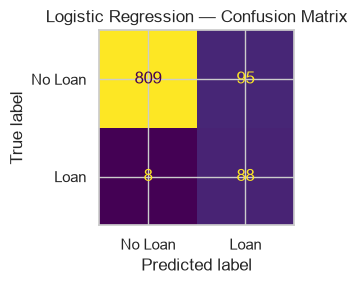

In [20]:
# Final Logistic Regression — scaled + class_weight='balanced'
lr_final = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(solver='liblinear', C=50, class_weight='balanced')),
])
lr_final.fit(X_train, y_train)
y_pred_lr = lr_final.predict(X_test)
evaluate('Logistic Regression', y_test, y_pred_lr)


### 6.3 K-Nearest Neighbors

KNN is a distance-based algorithm — **feature scaling is essential**. Without it, high-magnitude features like Income dominate the distance calculation and low-magnitude binary flags (Online, CreditCard) are effectively ignored.

We wrap KNN in a `Pipeline` with `StandardScaler` and sweep K = 1…29 to find the best number of neighbours.


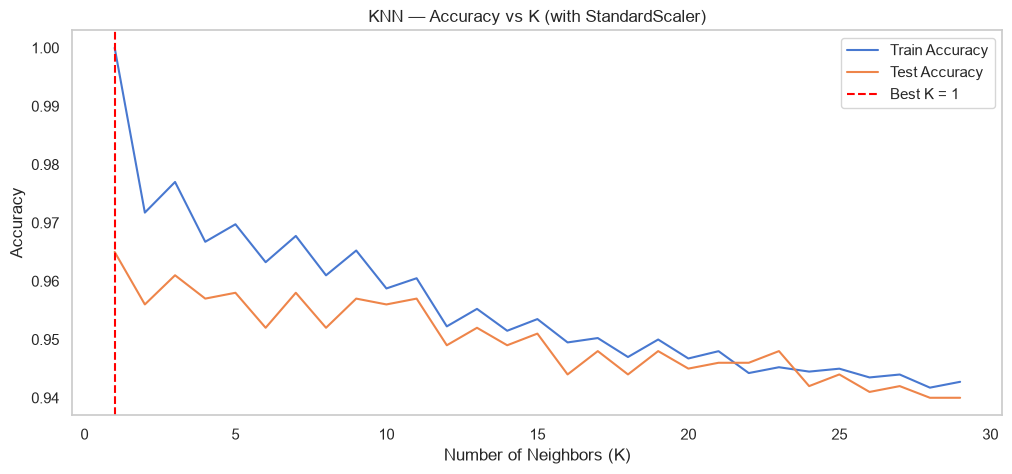

Best K: 1  |  Test Accuracy: 0.9650


In [21]:
tracc, testacc = [], []
k_range = range(1, 30)
for k in k_range:
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('knn', KNN(n_neighbors=k)),
    ])
    pipe.fit(X_train, y_train)
    tracc.append(pipe.score(X_train, y_train))
    testacc.append(pipe.score(X_test, y_test))

plt.figure(figsize=(12, 5))
plt.plot(k_range, tracc, label='Train Accuracy')
plt.plot(k_range, testacc, label='Test Accuracy')
best_k = list(k_range)[int(np.argmax(testacc))]
plt.axvline(best_k, color='red', linestyle='--', label=f'Best K = {best_k}')
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Accuracy')
plt.title('KNN — Accuracy vs K (with StandardScaler)')
plt.legend()
plt.grid()
plt.show()
print(f'Best K: {best_k}  |  Test Accuracy: {max(testacc):.4f}')


── KNN ──
              precision    recall  f1-score   support

     No Loan       0.97      0.99      0.98       904
        Loan       0.86      0.76      0.81        96

    accuracy                           0.96      1000
   macro avg       0.92      0.87      0.89      1000
weighted avg       0.96      0.96      0.96      1000



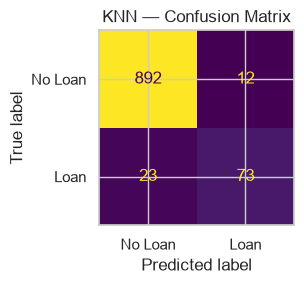

In [22]:
knn_final = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNN(n_neighbors=best_k)),
])
knn_final.fit(X_train, y_train)
y_pred_knn = knn_final.predict(X_test)
evaluate('KNN', y_test, y_pred_knn)


### 6.4 Complement Naive Bayes

── Complement Naive Bayes ──
              precision    recall  f1-score   support

     No Loan       0.97      0.76      0.85       904
        Loan       0.26      0.80      0.39        96

    accuracy                           0.76      1000
   macro avg       0.62      0.78      0.62      1000
weighted avg       0.90      0.76      0.81      1000



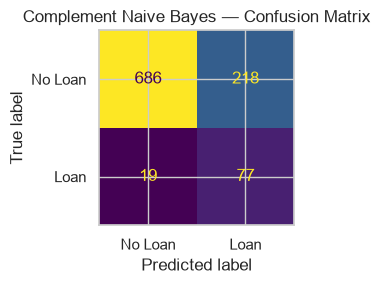

In [23]:
nb = ComplementNB()
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)
evaluate('Complement Naive Bayes', y_test, y_pred_nb)

## 7. Model Comparison

In [24]:
results = {
    'Logistic Regression': y_pred_lr,
    'KNN':                 y_pred_knn,
    'Naive Bayes':         y_pred_nb,
}

summary = pd.DataFrame([
    {
        'Model': name,
        'Accuracy': metrics.accuracy_score(y_test, ypred),
        'Precision': metrics.precision_score(y_test, ypred),
        'Recall': metrics.recall_score(y_test, ypred),
        'F1 Score': metrics.f1_score(y_test, ypred),
    }
    for name, ypred in results.items()
])

summary.set_index('Model').style.highlight_max(color='lightgreen').format('{:.4f}')

,Accuracy,Precision,Recall,F1 Score
Model,,,,
Logistic Regression,0.8970,0.4809,0.9167,0.6308
KNN,0.9650,0.8588,0.7604,0.8066
Naive Bayes,0.7630,0.2610,0.8021,0.3939


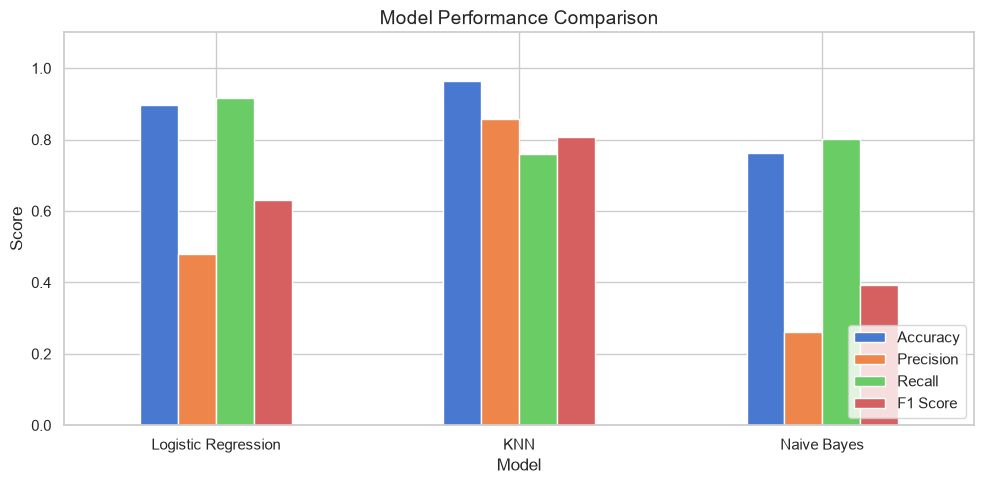

In [25]:
# Bar chart comparison
ax = summary.set_index('Model').plot(kind='bar', figsize=(10, 5), rot=0)
ax.set_ylim(0, 1.1)
ax.set_title('Model Performance Comparison', fontsize=14)
ax.set_ylabel('Score')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 8. Conclusions

- **KNN** benefits significantly from `StandardScaler` — distance-based methods are sensitive to feature magnitude.
- **Logistic Regression** with `StandardScaler` + `class_weight='balanced'` improves recall on the minority class (loan acceptors), which is usually what matters most to a bank.
- **Naive Bayes** underperforms here because the feature-independence assumption doesn't hold well for correlated financial data.
- The dataset is **imbalanced** (~9% positive). F1 Score and Recall are more meaningful metrics than raw accuracy.
- Using a `Pipeline` ensures the scaler is always fit on training data only — no data leakage.
